### Step-1: Business Problem Solving
What relationship between eaach advertising channel(TV , Radio, Newspaper) and sales



In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

### Step-2-1: Dala Collection

In [2]:
df=pd.read_csv(r'C:\Users\nagasri15\Downloads\Advertising.csv')
df

,TV,radio,newspaper,sales
0,230100,37800,69200,22100
1,44500,39300,45100,10400
2,17200,45900,69300,9300
3,151500,41300,58500,18500
4,180800,10800,58400,12900
...,...,...,...,...
195,38200,3700,13800,7600
196,94200,4900,8100,9700
197,177000,9300,6400,12800
198,283600,42000,66200,25500


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   TV         200 non-null    int64
 1   radio      200 non-null    int64
 2   newspaper  200 non-null    int64
 3   sales      200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [4]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147042.500000,23264.000000,30554.000000,14022.500000
std,85854.236315,14846.809176,21778.620839,5217.456566
min,700.000000,0.000000,300.000000,1600.000000
25%,74375.000000,9975.000000,12750.000000,10375.000000
50%,149750.000000,22900.000000,25750.000000,12900.000000
75%,218825.000000,36525.000000,45100.000000,17400.000000
max,296400.000000,49600.000000,114000.000000,27000.000000


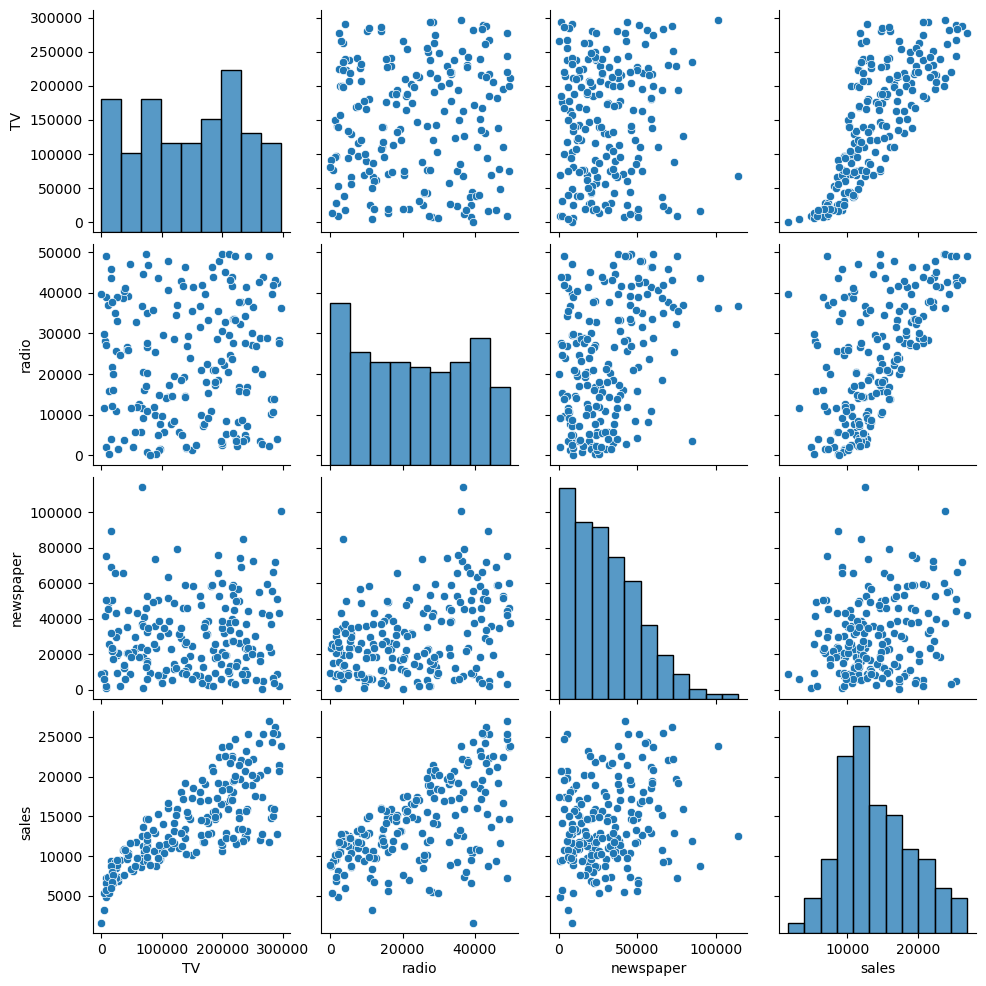

In [5]:
sns.pairplot(df)
plt.show()

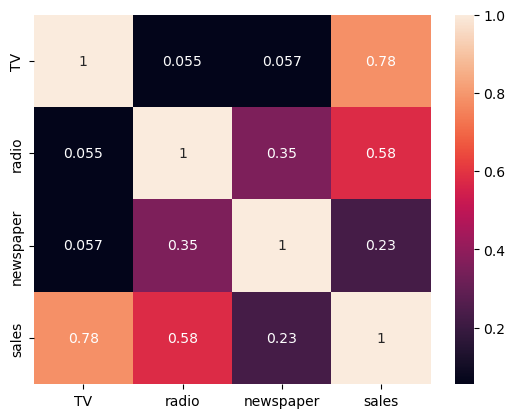

In [6]:
sns.heatmap(df.corr(), annot=True)
plt.show()

### Data Cleaning

In [7]:
df.isnull().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

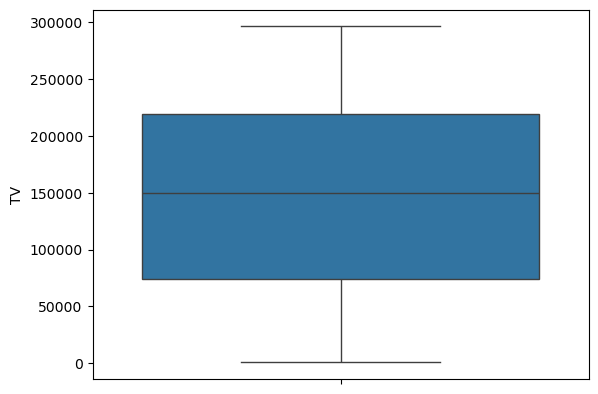

In [8]:
sns.boxplot(df["TV"])
plt.show()

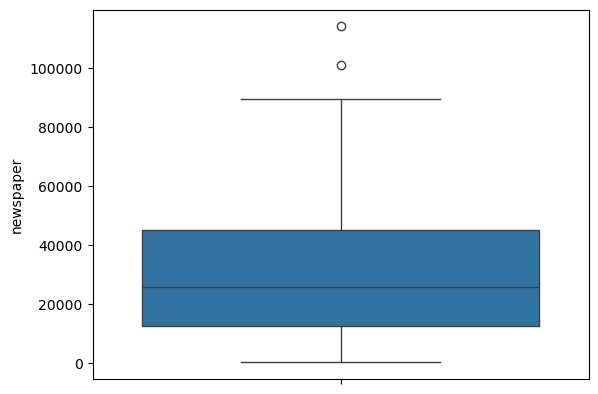

In [9]:
sns.boxplot(df["newspaper"])
plt.show()

In [10]:
df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


In [11]:
!pip install feature_engine
from feature_engine.outliers import Winsorizer
win = Winsorizer(capping_method = 'iqr', tail = 'both', fold = 1.5, variables = ['newspaper'])
df = win.fit_transform(df)
df

,TV,radio,newspaper,sales
0,230100,37800,69200,22100
1,44500,39300,45100,10400
2,17200,45900,69300,9300
3,151500,41300,58500,18500
4,180800,10800,58400,12900
...,...,...,...,...
195,38200,3700,13800,7600
196,94200,4900,8100,9700
197,177000,9300,6400,12800
198,283600,42000,66200,25500


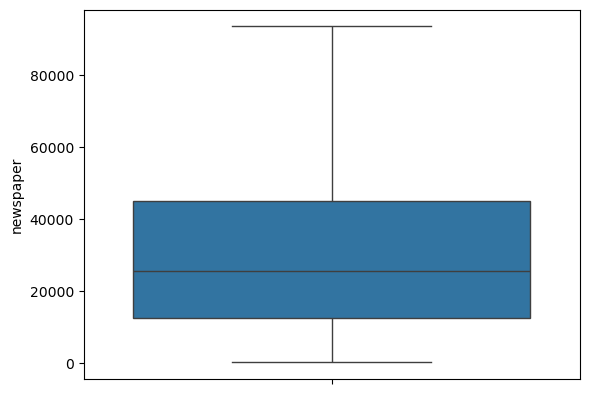

In [12]:
sns.boxplot(df["newspaper"])
plt.show()

### Train test split

In [13]:
x = df.drop(columns ='sales')
y = df['sales']

In [14]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 45)

In [15]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_converter = PolynomialFeatures(degree = 2, include_bias = False)
x_train = pd.DataFrame(polynomial_converter.fit_transform(x_train))
x_test = pd.DataFrame(polynomial_converter.transform(x_test))

In [16]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
model.intercept_

np.float64(4952.116284444388)

In [18]:
model.coef_

array([ 5.50310504e-02,  5.05912361e-03,  9.62987688e-03, -1.21163355e-07,
        1.14770627e-06, -5.44633681e-08,  2.74126011e-07,  1.10890961e-07,
       -1.90447875e-09])

### Prediction

In [19]:
train_predictions=model.predict(x_train)

In [20]:
test_predictions=model.predict(x_test)

### Evaluation

In [21]:
from sklearn.metrics import mean_absolute_error
print('MAE for test data:',mean_absolute_error(y_test,test_predictions))
print('MAE for train data:',mean_absolute_error(y_train,train_predictions))

MAE for test data: 488.8779785043385
MAE for train data: 427.0973210454506


In [22]:
from sklearn.metrics import mean_squared_error
print('MSE for test data:',mean_squared_error(y_test,test_predictions))
print('MSE for train data:',mean_squared_error(y_train,train_predictions))

MSE for test data: 315610.8908926006
MSE for train data: 409239.81329286005


In [23]:
print("RMSE for test data: ",np.sqrt(mean_squared_error(y_test,test_predictions)))
print("RMSE for train data: ",np.sqrt(mean_squared_error(y_train,train_predictions)))

RMSE for test data:  561.7925692749955
RMSE for train data:  639.7185422456192


In [24]:
from sklearn.metrics import r2_score
print("R2 for test data: ",r2_score(y_test,test_predictions))
print("R2 for train data: ",r2_score(y_train,train_predictions))

R2 for test data:  0.987061290293702
R2 for train data:  0.9852380500914673


In [25]:
model.score(x_test,y_test)

0.987061290293702

In [26]:
model.score(x_train,y_train)

0.9852380500914673

### Cross Validation

In [27]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,x,y,cv=2)
print(scores)
cv_score=scores.mean()
print('Cross Validation Score:',cv_score)

[0.90384236 0.87775045]
Cross Validation Score: 0.890796402865986


In [28]:
#from sklearn.preprocessing import PolynomialFeatures
#polynomial_converter = PolynomialFeatures(degree = 2, include_bias = False)
#x_train = pd.DataFrame(polynomial_converter.fit_transform(x_train))
#x_test = pd.DataFrame(polynomial_converter.transform(x_test))

#from sklearn.model_selection import train_test_split
#x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 45)

#from sklearn.linear_model import LinearRegression
#model = LinearRegression()
#model.fit(x_train,y_train)

#train_predictions=model.predict(x_train)
#test_predictions=model.predict(x_test)

#print(model.score(x_test,y_test))
#print(model.score(x_train,y_train))